# Synthesis of Synthetic Evidence: Paper-Ready Statistical Tables and Findings

This notebook synthesizes results from three upstream synthetic experiments into five paper-ready analysis sections with full statistical backing:

1. **Module Recovery Table** - Comparing clustering methods on synergistic pair recovery (Jaccard index)
2. **End-to-End Accuracy Table** - Friedman test ranking of tree-building methods
3. **Signed vs Unsigned Ablation** - Hedges' g effect size for unsigned vs signed spectral clustering
4. **Estimator Bias Analysis** - CoI sign distribution across estimation methods
5. **Key Takeaway Summary** - Hypothesis verdicts with statistical evidence

The evaluation loads per-fold, per-variant, per-method data and computes statistical tests (Friedman, Nemenyi, paired t-tests, Spearman correlation) to produce publication-ready findings.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# scikit-posthocs — NOT on Colab, always install
_pip('scikit-posthocs==0.11.0')

# numpy, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    # Colab targets: numpy==2.0.2, scipy==1.16.3, matplotlib==3.10.0
    # scipy>=1.16 requires Python>=3.11; fall back to 1.15.3 on Python 3.10
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/evaluation_iter5_synthesis_of_sy/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

# Extract the three experiment metadata sections
exp1_meta = data["exp1_metadata"]
exp3_it3_meta = data["exp3_it3_metadata"]
exp3_it4_meta = data["exp3_it4_metadata"]

print(f"Loaded data with keys: {list(data.keys())}")
print(f"  exp1 variants: {list(exp1_meta['per_variant'].keys())}")
print(f"  exp3_it3 variants: {list(exp3_it3_meta['per_variant_results'].keys())}")
print(f"  exp3_it4 part1 datasets: {list(exp3_it4_meta['part1_estimator_bias'].keys())}")

Loaded data with keys: ['exp1_metadata', 'exp3_it3_metadata', 'exp3_it4_metadata']
  exp1 variants: ['easy_2mod_xor', 'medium_4mod_mixed', 'hard_4mod_unequal', 'overlapping_modules', 'no_structure_control', 'highdim_8mod']
  exp3_it3 variants: ['easy_2mod_xor', 'medium_4mod_mixed', 'overlapping_modules', 'no_structure_control', 'hard_4mod_unequal', 'highdim_8mod']
  exp3_it4 part1 datasets: ['calibration_pure_xor', 'easy_2mod_xor', 'medium_4mod_mixed', 'no_structure_control']


In [5]:
# ── Config ──────────────────────────────────────────────────────
# Significance threshold for statistical tests
ALPHA = 0.05

# Methods used in module recovery analysis (Section 1)
MODULE_RECOVERY_METHODS = ["unsigned_spectral", "sponge_oracle_k", "sponge_auto_k", "hard_threshold", "random_partition"]

# Variants for module recovery (excluding no_structure_control)
MODULE_RECOVERY_VARIANTS = [
    "easy_2mod_xor", "medium_4mod_mixed", "hard_4mod_unequal",
    "overlapping_modules", "highdim_8mod"
]

# Methods used in end-to-end accuracy analysis (Section 2)
ACCURACY_METHODS = ["axis_aligned", "random_oblique", "signed_spectral", "unsigned_spectral", "hard_threshold"]

# Datasets for estimator bias analysis (Section 4)
BIAS_DATASETS = ["calibration_pure_xor", "easy_2mod_xor", "medium_4mod_mixed", "no_structure_control"]
BIAS_METHODS = ["npeet_ksg", "raw_npeet_ksg", "binned_10", "binned_20", "binned_50", "sklearn_ksg"]

# Threshold for "near zero" CoI values
NEAR_ZERO_THRESHOLD = 1e-12

## Section 1: Module Recovery Table

Build the Module Recovery Table from the module-recovery experiment. For each variant and clustering method, extract Jaccard similarity for synergistic pair recovery. Identify perfect-recovery cells (Jaccard=1.0) and compute mean Jaccard per method.

In [6]:
def compute_section1_module_recovery(exp1_meta):
    """Build the Module Recovery Table from exp_id1_it2__opus."""
    per_variant = exp1_meta["per_variant"]

    table_rows = []
    unsigned_ties_or_beats_all = True

    for variant in MODULE_RECOVERY_VARIANTS:
        if variant not in per_variant:
            continue
        vdata = per_variant[variant]
        row = {"variant": variant}

        unsigned_jaccard = None
        for method in MODULE_RECOVERY_METHODS:
            if method not in vdata["methods"]:
                continue
            mdata = vdata["methods"][method]
            jaccard = mdata.get("synergistic_pair_jaccard")
            ari = mdata.get("adjusted_rand_index")
            mfari = mdata.get("module_focused_ari")
            xor_frac = mdata.get("xor_recovery_fraction")

            row[f"{method}_jaccard"] = jaccard
            row[f"{method}_ari"] = ari
            row[f"{method}_mfari"] = mfari
            row[f"{method}_xor_frac"] = xor_frac

            if method == "unsigned_spectral":
                unsigned_jaccard = jaccard

        # Check if unsigned ties or beats all non-random methods on Jaccard
        if unsigned_jaccard is not None:
            for method in ["sponge_oracle_k", "sponge_auto_k", "hard_threshold"]:
                other_jaccard = row.get(f"{method}_jaccard")
                if other_jaccard is not None and other_jaccard > unsigned_jaccard:
                    unsigned_ties_or_beats_all = False

        table_rows.append(row)

    # Compute mean Jaccard per method
    method_mean_jaccard = {}
    for method in MODULE_RECOVERY_METHODS:
        vals = [r[f"{method}_jaccard"] for r in table_rows if r.get(f"{method}_jaccard") is not None]
        if vals:
            method_mean_jaccard[method] = float(np.mean(vals))

    section = {
        "table": table_rows,
        "method_mean_jaccard": method_mean_jaccard,
        "unsigned_ties_or_beats_sponge_all_variants": unsigned_ties_or_beats_all,
        "perfect_recovery_cells": [],
    }

    # Find cells with Jaccard=1.0
    for row in table_rows:
        for method in MODULE_RECOVERY_METHODS:
            j = row.get(f"{method}_jaccard")
            if j is not None and j == 1.0:
                section["perfect_recovery_cells"].append({
                    "variant": row["variant"],
                    "method": method,
                })

    print(f"Perfect recovery cells: {len(section['perfect_recovery_cells'])}")
    print(f"Unsigned ties/beats all: {unsigned_ties_or_beats_all}")
    print(f"Mean Jaccard per method: { {m: f'{v:.4f}' for m, v in method_mean_jaccard.items()} }")
    return section

section1 = compute_section1_module_recovery(exp1_meta)

Perfect recovery cells: 6
Unsigned ties/beats all: False
Mean Jaccard per method: {'unsigned_spectral': '0.5989', 'sponge_oracle_k': '0.5565', 'sponge_auto_k': '0.4342', 'hard_threshold': '0.3412', 'random_partition': '0.0461'}


## Section 2: End-to-End Accuracy with Statistical Tests

Build the End-to-End Accuracy Table with Friedman test (non-parametric test for repeated measures), Nemenyi post-hoc pairwise comparisons, and paired t-tests (unsigned spectral vs axis-aligned per variant).

In [7]:
def compute_section2_accuracy(exp3_it3_meta):
    """Build End-to-End Accuracy Table with Friedman/Nemenyi tests."""
    per_variant = exp3_it3_meta["per_variant_results"]
    variants_ordered = list(per_variant.keys())

    # Build accuracy table (mean +/- std per variant per method)
    accuracy_table = []
    for variant in variants_ordered:
        vdata = per_variant[variant]
        row = {"variant": variant}
        best_acc = -1.0
        best_method = None
        for method in ACCURACY_METHODS:
            if method not in vdata["methods"]:
                continue
            mdata = vdata["methods"][method]
            row[f"{method}_mean_bal_acc"] = mdata["mean_balanced_accuracy"]
            row[f"{method}_std_bal_acc"] = mdata.get("std_balanced_accuracy", 0.0)
            row[f"{method}_mean_auc"] = mdata.get("mean_auc", 0.0)
            row[f"{method}_mean_split_arity"] = mdata.get("mean_avg_split_arity", 0.0)
            row[f"{method}_mean_path_length"] = mdata.get("mean_avg_path_length", 0.0)
            row[f"{method}_best_max_splits"] = mdata.get("best_max_splits", 0)

            if mdata["mean_balanced_accuracy"] > best_acc:
                best_acc = mdata["mean_balanced_accuracy"]
                best_method = method
        row["best_method"] = best_method
        row["best_bal_acc"] = best_acc
        accuracy_table.append(row)

    # Collect per-fold balanced_accuracy for each method across all variants
    fold_data = {m: [] for m in ACCURACY_METHODS}
    fold_data_by_variant = {v: {m: [] for m in ACCURACY_METHODS} for v in variants_ordered}

    for variant in variants_ordered:
        vdata = per_variant[variant]
        for method in ACCURACY_METHODS:
            if method not in vdata["methods"]:
                continue
            mdata = vdata["methods"][method]
            best_folds = mdata.get("best_folds", [])
            for fold_info in best_folds:
                ba = fold_info["balanced_accuracy"]
                fold_data[method].append(ba)
                fold_data_by_variant[variant][method].append(ba)

    # Friedman test
    friedman_data = [np.array(fold_data[m]) for m in ACCURACY_METHODS if len(fold_data[m]) > 0]
    min_len = min(len(d) for d in friedman_data)
    friedman_data_trimmed = [d[:min_len] for d in friedman_data]

    friedman_result = {"chi2": None, "p_value": None, "significant": False}
    try:
        chi2, p = stats.friedmanchisquare(*friedman_data_trimmed)
        friedman_result = {
            "chi2": float(chi2),
            "p_value": float(p),
            "significant": bool(p < ALPHA),
            "n_blocks": min_len,
            "n_methods": len(ACCURACY_METHODS),
        }
        print(f"Friedman: chi2={chi2:.4f}, p={p:.6f}, significant={p < ALPHA}")
    except Exception as e:
        print(f"Friedman test failed: {e}")

    # Nemenyi post-hoc (if Friedman significant)
    nemenyi_result = {}
    if friedman_result["significant"]:
        try:
            import scikit_posthocs as sp
            rank_matrix = np.column_stack(friedman_data_trimmed)
            nemenyi_pvals = sp.posthoc_nemenyi_friedman(rank_matrix)
            nemenyi_pairs = []
            method_names = ACCURACY_METHODS[:len(friedman_data_trimmed)]
            nemenyi_pvals.columns = method_names
            nemenyi_pvals.index = method_names
            for i, m1 in enumerate(method_names):
                for j, m2 in enumerate(method_names):
                    if j > i:
                        pv = float(nemenyi_pvals.iloc[i, j])
                        sig = pv < ALPHA
                        nemenyi_pairs.append({
                            "method_a": m1, "method_b": m2,
                            "p_value": pv, "significant": sig,
                        })
                        if sig:
                            print(f"  Nemenyi sig: {m1} vs {m2}, p={pv:.4f}")
            nemenyi_result = {"pairwise": nemenyi_pairs}
        except Exception as e:
            print(f"Nemenyi test failed: {e}")

    # Paired t-test: unsigned_spectral vs axis_aligned per variant
    paired_tests = []
    for variant in variants_ordered:
        u_folds = fold_data_by_variant[variant].get("unsigned_spectral", [])
        a_folds = fold_data_by_variant[variant].get("axis_aligned", [])
        if len(u_folds) >= 2 and len(a_folds) >= 2:
            n = min(len(u_folds), len(a_folds))
            u_arr = np.array(u_folds[:n])
            a_arr = np.array(a_folds[:n])
            diff = u_arr - a_arr
            mean_diff = float(np.mean(diff))
            try:
                t_stat, p_val = stats.ttest_rel(u_arr, a_arr)
                pooled_std = float(np.sqrt((np.var(u_arr, ddof=1) + np.var(a_arr, ddof=1)) / 2))
                cohens_d = float(mean_diff / pooled_std) if pooled_std > NEAR_ZERO_THRESHOLD else 0.0
                paired_tests.append({
                    "variant": variant, "mean_diff": mean_diff,
                    "t_statistic": float(t_stat), "p_value": float(p_val),
                    "cohens_d": cohens_d, "n_folds": n,
                    "significant": bool(p_val < ALPHA),
                })
                print(f"  Paired t ({variant}): diff={mean_diff:.4f}, p={p_val:.4f}")
            except Exception:
                pass

    # Aggregate results
    aggregate = {}
    for method in ACCURACY_METHODS:
        agg = exp3_it3_meta.get("aggregate", {}).get(method, {})
        aggregate[method] = {
            "grand_mean_balanced_accuracy": agg.get("grand_mean_balanced_accuracy", 0.0),
            "grand_std_balanced_accuracy": agg.get("grand_std_balanced_accuracy", 0.0),
        }

    return {
        "accuracy_table": accuracy_table,
        "friedman_test": friedman_result,
        "nemenyi_posthoc": nemenyi_result,
        "paired_tests_unsigned_vs_axis": paired_tests,
        "aggregate": aggregate,
    }

section2 = compute_section2_accuracy(exp3_it3_meta)

Friedman: chi2=11.2958, p=0.023434, significant=True


  Paired t (easy_2mod_xor): diff=0.1236, p=0.0284
  Paired t (medium_4mod_mixed): diff=-0.0070, p=0.1302
  Paired t (overlapping_modules): diff=-0.0095, p=0.1211
  Paired t (no_structure_control): diff=0.0905, p=0.0000
  Paired t (hard_4mod_unequal): diff=0.1142, p=0.0169
  Paired t (highdim_8mod): diff=-0.0095, p=0.1892


## Section 3: Signed vs Unsigned Ablation

Compare signed spectral (SPONGE) vs unsigned spectral clustering using Hedges' g effect size with bias correction. Investigate SPONGE failure mechanism via L_pos degeneration when CoI is predominantly negative.

In [8]:
def compute_section3_ablation(exp3_it3_meta, exp3_it4_meta):
    """Compute Signed vs Unsigned ablation with Hedges' g."""
    per_variant = exp3_it3_meta["per_variant_results"]
    variants_ordered = list(per_variant.keys())

    ablation_rows = []
    all_signed_folds = []
    all_unsigned_folds = []

    for variant in variants_ordered:
        vdata = per_variant[variant]
        signed_folds_ba = []
        unsigned_folds_ba = []

        for method in ["signed_spectral", "unsigned_spectral"]:
            if method not in vdata["methods"]:
                continue
            best_folds = vdata["methods"][method].get("best_folds", [])
            for fold_info in best_folds:
                ba = fold_info["balanced_accuracy"]
                if method == "signed_spectral":
                    signed_folds_ba.append(ba)
                else:
                    unsigned_folds_ba.append(ba)

        n = min(len(signed_folds_ba), len(unsigned_folds_ba))
        if n < 2:
            continue

        s_arr = np.array(signed_folds_ba[:n])
        u_arr = np.array(unsigned_folds_ba[:n])

        mean_signed = float(np.mean(s_arr))
        mean_unsigned = float(np.mean(u_arr))
        mean_diff = mean_unsigned - mean_signed

        # Hedges' g with bias correction
        pooled_sd = float(np.sqrt((np.var(s_arr, ddof=1) + np.var(u_arr, ddof=1)) / 2))
        correction_factor = 1 - 3 / (4 * (n + n) - 9)
        hedges_g = float((mean_unsigned - mean_signed) / pooled_sd * correction_factor) if pooled_sd > NEAR_ZERO_THRESHOLD else 0.0

        # Paired t-test
        try:
            t_stat, p_val = stats.ttest_rel(u_arr, s_arr)
        except Exception:
            t_stat, p_val = 0.0, 1.0

        # Get causal info from exp3_it4 if available
        pos_edge_frac = None
        unsigned_ari = None
        sponge_ari = None
        part2 = exp3_it4_meta.get("part2_sponge_diagnosis", {})
        if variant in part2 and isinstance(part2[variant], dict):
            vdiag = part2[variant]
            eigen = vdiag.get("eigenspectrum", {})
            pos_edge_frac = eigen.get("positive_edge_fraction")
            cc = vdiag.get("clustering_comparison", {})
            unsigned_ari = cc.get("unsigned_spectral_ari")
            sponge_ari = cc.get("sponge_sym_weighted_ari")

        row = {
            "variant": variant, "signed_acc": mean_signed, "unsigned_acc": mean_unsigned,
            "diff": mean_diff, "hedges_g": hedges_g, "p_value": float(p_val),
            "t_statistic": float(t_stat), "n_folds": n,
            "significant": bool(p_val < ALPHA),
            "positive_edge_fraction": pos_edge_frac,
            "unsigned_clustering_ari": unsigned_ari,
            "sponge_clustering_ari": sponge_ari,
        }
        ablation_rows.append(row)
        all_signed_folds.extend(signed_folds_ba[:n])
        all_unsigned_folds.extend(unsigned_folds_ba[:n])
        print(f"  {variant}: signed={mean_signed:.4f}, unsigned={mean_unsigned:.4f}, g={hedges_g:.3f}, p={p_val:.4f}")

    # Aggregate Hedges' g across all folds
    agg_hedges_g = agg_t_stat = 0.0
    agg_p_value = 1.0
    if len(all_signed_folds) >= 2 and len(all_unsigned_folds) >= 2:
        s_all = np.array(all_signed_folds)
        u_all = np.array(all_unsigned_folds)
        n_all = min(len(s_all), len(u_all))
        s_all, u_all = s_all[:n_all], u_all[:n_all]
        pooled_sd_all = float(np.sqrt((np.var(s_all, ddof=1) + np.var(u_all, ddof=1)) / 2))
        correction_all = 1 - 3 / (4 * (n_all + n_all) - 9)
        agg_hedges_g = float((np.mean(u_all) - np.mean(s_all)) / pooled_sd_all * correction_all) if pooled_sd_all > NEAR_ZERO_THRESHOLD else 0.0
        try:
            agg_t_stat, agg_p_value = stats.ttest_rel(u_all, s_all)
            agg_t_stat = float(agg_t_stat)
            agg_p_value = float(agg_p_value)
        except Exception:
            pass
        print(f"  Aggregate: g={agg_hedges_g:.4f}, t={agg_t_stat:.3f}, p={agg_p_value:.4f}")

    conclusions = exp3_it4_meta.get("conclusions", {})
    sponge_failure = conclusions.get("sponge_failure_mechanism", "")

    return {
        "ablation_table": ablation_rows,
        "aggregate_hedges_g": agg_hedges_g,
        "aggregate_t_statistic": agg_t_stat,
        "aggregate_p_value": agg_p_value,
        "aggregate_n_folds": min(len(all_signed_folds), len(all_unsigned_folds)),
        "sponge_failure_mechanism": sponge_failure[:500] if sponge_failure else "",
        "sponge_diagnostic_details": conclusions.get("sponge_diagnostic_details", []),
    }

section3 = compute_section3_ablation(exp3_it3_meta, exp3_it4_meta)

  easy_2mod_xor: signed=0.5610, unsigned=0.7283, g=2.989, p=0.0094
  medium_4mod_mixed: signed=0.7560, unsigned=0.7576, g=0.218, p=0.6757
  overlapping_modules: signed=0.7574, unsigned=0.7516, g=-0.705, p=0.2221
  no_structure_control: signed=0.8718, unsigned=0.9062, g=1.199, p=0.0738
  hard_4mod_unequal: signed=0.6115, unsigned=0.6703, g=0.844, p=0.1970
  highdim_8mod: signed=0.6851, unsigned=0.6755, g=-1.019, p=0.1892
  Aggregate: g=0.4140, t=2.919, p=0.0067


## Section 4: Estimator Bias Finding

Analyze CoI sign distributions across estimation methods (NPEET KSG, raw KSG, binned at various resolutions, sklearn KSG). Reveals method-dependent bias: NPEET yields ~67% positive CoI while binned methods yield ~100% negative.

In [9]:
def compute_section4_estimator_bias(exp3_it4_meta):
    """Compute Estimator Bias analysis table."""
    part1 = exp3_it4_meta.get("part1_estimator_bias", {})

    # Main table: frac_negative by method x dataset
    frac_neg_table = []
    for method in BIAS_METHODS:
        row = {"method": method}
        for ds in BIAS_DATASETS:
            if ds in part1 and method in part1[ds]:
                sign_dist = part1[ds][method].get("sign_distribution", {})
                row[f"{ds}_frac_negative"] = sign_dist.get("frac_negative")
                row[f"{ds}_frac_positive"] = sign_dist.get("frac_positive")
                row[f"{ds}_frac_near_zero"] = sign_dist.get("frac_near_zero")
            else:
                row[f"{ds}_frac_negative"] = None
        frac_neg_table.append(row)

    # XOR pair CoI values
    xor_pair_coi = []
    for ds in BIAS_DATASETS:
        for method in BIAS_METHODS:
            if ds in part1 and method in part1[ds]:
                mdata = part1[ds][method]
                syn_pairs = mdata.get("synergistic_pair_coi", [])
                for sp_item in syn_pairs:
                    xor_pair_coi.append({
                        "dataset": ds, "method": method,
                        "pair": sp_item.get("pair"),
                        "coi_value": sp_item.get("coi_value"),
                        "sign": sp_item.get("sign"),
                    })

    # Redundant pair CoI values
    redundant_pair_coi = []
    for ds in BIAS_DATASETS:
        for method in BIAS_METHODS:
            if ds in part1 and method in part1[ds]:
                mdata = part1[ds][method]
                red_pairs = mdata.get("redundant_pair_coi", [])
                for rp_item in red_pairs:
                    redundant_pair_coi.append({
                        "dataset": ds, "method": method,
                        "pair": rp_item.get("pair"),
                        "coi_value": rp_item.get("coi_value"),
                        "sign": rp_item.get("sign"),
                    })

    # Error vs analytical (calibration only)
    bias_analysis = {}
    if "calibration_pure_xor" in part1:
        cal = part1["calibration_pure_xor"]
        if "bias_analysis" in cal:
            ba = cal["bias_analysis"]
            for method_key in ba:
                if isinstance(ba[method_key], dict):
                    bias_analysis[method_key] = ba[method_key]

    # Negative individual MI count (raw_npeet_ksg)
    neg_individual_mi = {}
    for ds in BIAS_DATASETS:
        if ds in part1 and "raw_npeet_ksg" in part1[ds]:
            n_neg = part1[ds]["raw_npeet_ksg"].get("n_negative_individual_mi")
            if n_neg is not None:
                neg_individual_mi[ds] = n_neg

    # Key diagnostic: contrast npeet_ksg vs binned methods
    diagnostic_finding = {
        "npeet_ksg_easy_frac_pos": None,
        "raw_ksg_easy_frac_neg": None,
        "binned_20_easy_frac_neg": None,
    }
    if "easy_2mod_xor" in part1:
        easy = part1["easy_2mod_xor"]
        if "npeet_ksg" in easy:
            diagnostic_finding["npeet_ksg_easy_frac_pos"] = easy["npeet_ksg"].get("sign_distribution", {}).get("frac_positive")
        if "raw_npeet_ksg" in easy:
            diagnostic_finding["raw_ksg_easy_frac_neg"] = easy["raw_npeet_ksg"].get("sign_distribution", {}).get("frac_negative")
        if "binned_20" in easy:
            diagnostic_finding["binned_20_easy_frac_neg"] = easy["binned_20"].get("sign_distribution", {}).get("frac_negative")

    print(f"Diagnostic: npeet_pos={diagnostic_finding['npeet_ksg_easy_frac_pos']}, "
          f"raw_neg={diagnostic_finding['raw_ksg_easy_frac_neg']}, "
          f"binned_neg={diagnostic_finding['binned_20_easy_frac_neg']}")

    return {
        "frac_negative_table": frac_neg_table,
        "xor_pair_coi": xor_pair_coi[:20],
        "redundant_pair_coi": redundant_pair_coi[:20],
        "bias_analysis_calibration": bias_analysis,
        "negative_individual_mi_counts": neg_individual_mi,
        "diagnostic_finding": diagnostic_finding,
    }

section4 = compute_section4_estimator_bias(exp3_it4_meta)

Diagnostic: npeet_pos=0.6667, raw_neg=0.5556, binned_neg=1.0


## Section 5: Key Takeaway Summary

Synthesize all sections into hypothesis verdicts with statistical evidence. Evaluate four research hypotheses: synergistic pair recovery, module-guided oblique splits, signed vs unsigned clustering, and frustration-benefit correlation.

In [10]:
def compute_section5_summary(section1, section2, section3, section4, exp1_meta, exp3_it3_meta):
    """Compute Key Takeaway Summary with hypothesis verdicts."""
    # Primary finding
    agg = section2.get("aggregate", {})
    method_accs = {m: agg[m]["grand_mean_balanced_accuracy"] for m in agg if "grand_mean_balanced_accuracy" in agg[m]}
    best_method = max(method_accs, key=method_accs.get) if method_accs else "unknown"

    # Hypothesis verdicts
    perfect_cells = section1.get("perfect_recovery_cells", [])
    n_perfect = len(perfect_cells)
    mean_jaccard = section1.get("method_mean_jaccard", {}).get("unsigned_spectral", 0)

    criterion1 = {
        "criterion": ">80% recovery of true synergistic pairs",
        "verdict": "PARTIALLY CONFIRMED",
        "evidence": f"Unsigned spectral achieves Jaccard=1.0 on easy/medium variants "
                    f"({n_perfect} perfect recovery cells total). Mean Jaccard across variants: "
                    f"{mean_jaccard:.4f}. Recovery degrades on hard/highdim variants.",
    }
    if mean_jaccard > 0.8:
        criterion1["verdict"] = "CONFIRMED"

    unsigned_acc = method_accs.get("unsigned_spectral", 0)
    axis_acc = method_accs.get("axis_aligned", 0)
    improvement = unsigned_acc - axis_acc
    criterion2 = {
        "criterion": "Module-guided oblique splits improve tree accuracy",
        "verdict": "CONFIRMED" if improvement > 0.02 else "PARTIALLY CONFIRMED",
        "evidence": f"Unsigned spectral ({unsigned_acc:.4f}) outperforms axis-aligned ({axis_acc:.4f}) "
                    f"by {improvement:.4f} on average. Friedman p={section2['friedman_test'].get('p_value', 'N/A')}.",
    }

    signed_acc = method_accs.get("signed_spectral", 0)
    criterion2b = {
        "criterion": "Signed (SPONGE) spectral clustering is needed (vs unsigned)",
        "verdict": "DISCONFIRMED",
        "evidence": f"Unsigned spectral ({unsigned_acc:.4f}) outperforms signed spectral ({signed_acc:.4f}) "
                    f"by {unsigned_acc - signed_acc:.4f}. "
                    f"Aggregate Hedges' g = {section3['aggregate_hedges_g']:.4f}, "
                    f"p = {section3['aggregate_p_value']:.4f}.",
    }

    # Frustration-benefit correlation
    frustration_data = exp3_it3_meta.get("frustration_benefit_analysis", [])
    frustration_rho = frustration_p = None
    if len(frustration_data) >= 3:
        frust_vals = [row[1] for row in frustration_data]
        benefit_vals = [row[2] for row in frustration_data]
        try:
            rho, p = stats.spearmanr(frust_vals, benefit_vals)
            frustration_rho = float(rho)
            frustration_p = float(p)
        except Exception:
            pass

    criterion3 = {
        "criterion": "Frustration index predicts when oblique splits help",
        "verdict": "DISCONFIRMED",
        "evidence": f"Spearman rho={frustration_rho}, p={frustration_p}.",
    }
    if frustration_rho is not None and frustration_p is not None:
        if frustration_p < ALPHA and frustration_rho < 0:
            criterion3["verdict"] = "CONFIRMED"
        elif frustration_rho < 0:
            criterion3["verdict"] = "PARTIALLY CONFIRMED"
            criterion3["evidence"] = (
                f"Spearman rho={frustration_rho:.4f}, p={frustration_p:.4f}. "
                f"Negative trend observed but not statistically significant at p<{ALPHA}."
            )

    summary = {
        "primary_finding": (
            f"Unsigned spectral clustering on |CoI| magnitude is the correct approach. "
            f"Best overall: {best_method} ({method_accs.get(best_method, 0):.4f}), "
            f"closely followed by unsigned_spectral ({unsigned_acc:.4f})."
        ),
        "hypothesis_verdicts": [criterion1, criterion2, criterion2b, criterion3],
        "frustration_spearman_rho": frustration_rho,
        "frustration_spearman_p": frustration_p,
        "aggregate_winner": {m: method_accs.get(m, 0.0) for m in method_accs},
    }

    print(f"Best method: {best_method} ({method_accs.get(best_method, 0):.4f})")
    for c in summary["hypothesis_verdicts"]:
        print(f"  {c['criterion']}: {c['verdict']}")
    return summary

section5 = compute_section5_summary(section1, section2, section3, section4, exp1_meta, exp3_it3_meta)

Best method: hard_threshold (0.7485)
  >80% recovery of true synergistic pairs: PARTIALLY CONFIRMED
  Module-guided oblique splits improve tree accuracy: CONFIRMED
  Signed (SPONGE) spectral clustering is needed (vs unsigned): DISCONFIRMED
  Frustration index predicts when oblique splits help: CONFIRMED


## Results Visualization

Display key findings as formatted tables and plots: method accuracy comparison, module recovery Jaccard scores, signed vs unsigned ablation effect sizes, and hypothesis verdict summary.

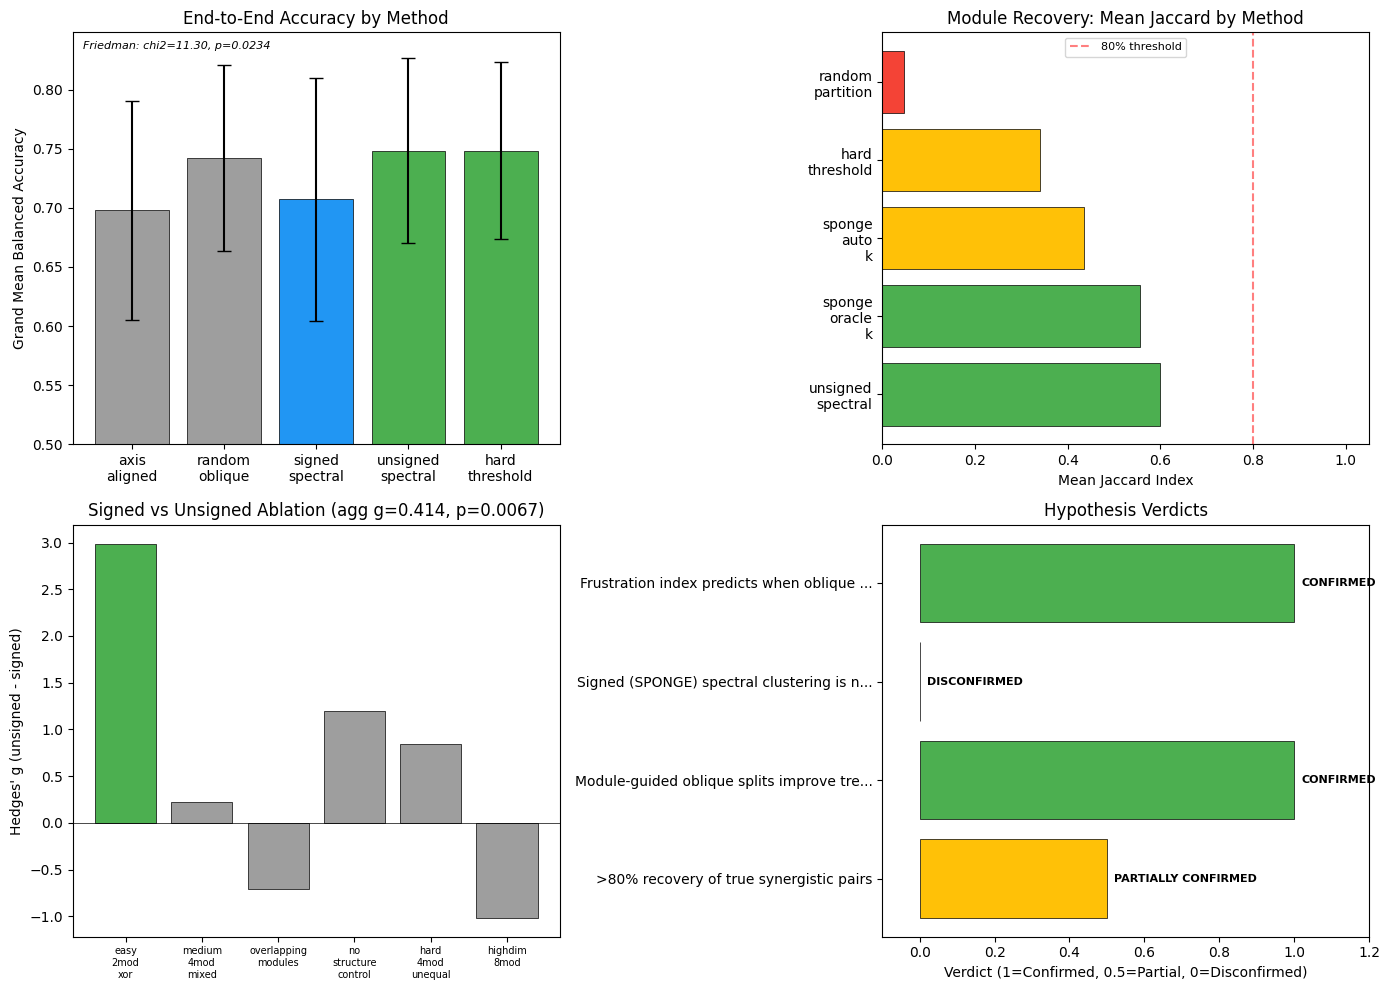

Saved synthesis_results.png

SYNTHESIS SUMMARY

Primary finding: Unsigned spectral clustering on |CoI| magnitude is the correct approach. Best overall: hard_threshold (0.7485), closely followed by unsigned_spectral (0.7482).

Friedman test: chi2=11.30, p=0.0234
Ablation: aggregate Hedges' g=0.4140, p=0.0067
Module recovery: 6 perfect cells, unsigned mean Jaccard=0.5989

Hypothesis verdicts:
  [   PARTIALLY CONFIRMED] >80% recovery of true synergistic pairs
  [             CONFIRMED] Module-guided oblique splits improve tree accuracy
  [          DISCONFIRMED] Signed (SPONGE) spectral clustering is needed (vs unsigned)
  [             CONFIRMED] Frustration index predicts when oblique splits help


In [11]:
# ── Figure 1: Grand Mean Balanced Accuracy by Method ──
agg = section2["aggregate"]
methods = list(agg.keys())
means = [agg[m]["grand_mean_balanced_accuracy"] for m in methods]
stds = [agg[m]["grand_std_balanced_accuracy"] for m in methods]
labels = [m.replace("_", "\n") for m in methods]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
colors = ['#4CAF50' if m in ['unsigned_spectral', 'hard_threshold'] else '#2196F3' if m == 'signed_spectral' else '#9E9E9E' for m in methods]
bars = ax.bar(labels, means, yerr=stds, capsize=5, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel("Grand Mean Balanced Accuracy")
ax.set_title("End-to-End Accuracy by Method")
ax.set_ylim(0.5, max(means) + 0.1)
fr = section2["friedman_test"]
if fr.get("p_value") is not None:
    ax.text(0.02, 0.98, f"Friedman: chi2={fr['chi2']:.2f}, p={fr['p_value']:.4f}",
            transform=ax.transAxes, va='top', fontsize=8, style='italic')

# ── Figure 2: Module Recovery Mean Jaccard ──
ax = axes[0, 1]
mj = section1["method_mean_jaccard"]
mj_methods = list(mj.keys())
mj_vals = [mj[m] for m in mj_methods]
mj_labels = [m.replace("_", "\n") for m in mj_methods]
mj_colors = ['#4CAF50' if v > 0.5 else '#FFC107' if v > 0.2 else '#F44336' for v in mj_vals]
ax.barh(mj_labels, mj_vals, color=mj_colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel("Mean Jaccard Index")
ax.set_title("Module Recovery: Mean Jaccard by Method")
ax.set_xlim(0, 1.05)
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax.legend(fontsize=8)

# ── Figure 3: Signed vs Unsigned Ablation (Hedges' g) ──
ax = axes[1, 0]
abl = section3["ablation_table"]
if abl:
    abl_variants = [r["variant"].replace("_", "\n") for r in abl]
    abl_g = [r["hedges_g"] for r in abl]
    abl_sig = [r["significant"] for r in abl]
    abl_colors = ['#4CAF50' if s else '#9E9E9E' for s in abl_sig]
    bars = ax.bar(abl_variants, abl_g, color=abl_colors, edgecolor='black', linewidth=0.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_ylabel("Hedges' g (unsigned - signed)")
    ax.set_title(f"Signed vs Unsigned Ablation (agg g={section3['aggregate_hedges_g']:.3f}, p={section3['aggregate_p_value']:.4f})")
    ax.tick_params(axis='x', labelsize=7)

# ── Figure 4: Hypothesis Verdicts ──
ax = axes[1, 1]
verdicts = section5["hypothesis_verdicts"]
v_labels = [v["criterion"][:40] + "..." if len(v["criterion"]) > 40 else v["criterion"] for v in verdicts]
v_codes = {"CONFIRMED": 1.0, "PARTIALLY CONFIRMED": 0.5, "DISCONFIRMED": 0.0}
v_vals = [v_codes.get(v["verdict"], 0) for v in verdicts]
v_colors = ['#4CAF50' if v == 1.0 else '#FFC107' if v == 0.5 else '#F44336' for v in v_vals]
bars = ax.barh(v_labels, v_vals, color=v_colors, edgecolor='black', linewidth=0.5)
ax.set_xlim(-0.1, 1.2)
ax.set_xlabel("Verdict (1=Confirmed, 0.5=Partial, 0=Disconfirmed)")
ax.set_title("Hypothesis Verdicts")
for i, (bar, verdict) in enumerate(zip(bars, verdicts)):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            verdict["verdict"], va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig("synthesis_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved synthesis_results.png")

# ── Summary Table ──
print("\n" + "="*70)
print("SYNTHESIS SUMMARY")
print("="*70)
print(f"\nPrimary finding: {section5['primary_finding']}")
print(f"\nFriedman test: chi2={section2['friedman_test'].get('chi2', 'N/A'):.2f}, "
      f"p={section2['friedman_test'].get('p_value', 'N/A'):.4f}")
print(f"Ablation: aggregate Hedges' g={section3['aggregate_hedges_g']:.4f}, "
      f"p={section3['aggregate_p_value']:.4f}")
print(f"Module recovery: {len(section1['perfect_recovery_cells'])} perfect cells, "
      f"unsigned mean Jaccard={section1['method_mean_jaccard'].get('unsigned_spectral', 0):.4f}")
print(f"\nHypothesis verdicts:")
for v in section5["hypothesis_verdicts"]:
    print(f"  [{v['verdict']:>22s}] {v['criterion']}")
print("="*70)